# Classifier Performance: All vs. Reduced Features
Bar plot comparing cross-validated performance metrics for All Features vs. Reduced Features models.
Error bars represent ± 1 SD across CV folds.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


In [15]:
# ── Data ──────────────────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Balanced\nAccuracy', 'ROC-AUC', 'F1', 'Precision', 'Recall']

all_mean = [0.850, 0.764, 0.921, 0.668, 0.917, 0.462]
all_sd   = [0.058, 0.089, 0.049, 0.167, 0.134, 0.185]

red_mean = [0.900, 0.841, 0.955, 0.797, 0.948, 0.705]
red_sd   = [0.034, 0.054, 0.022, 0.075, 0.083, 0.124]

dw_mean = [0.893, 0.827, 0.952, 0.776, 0.936, 0.676]
dw_sd   = [0.039, 0.061, 0.034, 0.090, 0.103, 0.122]


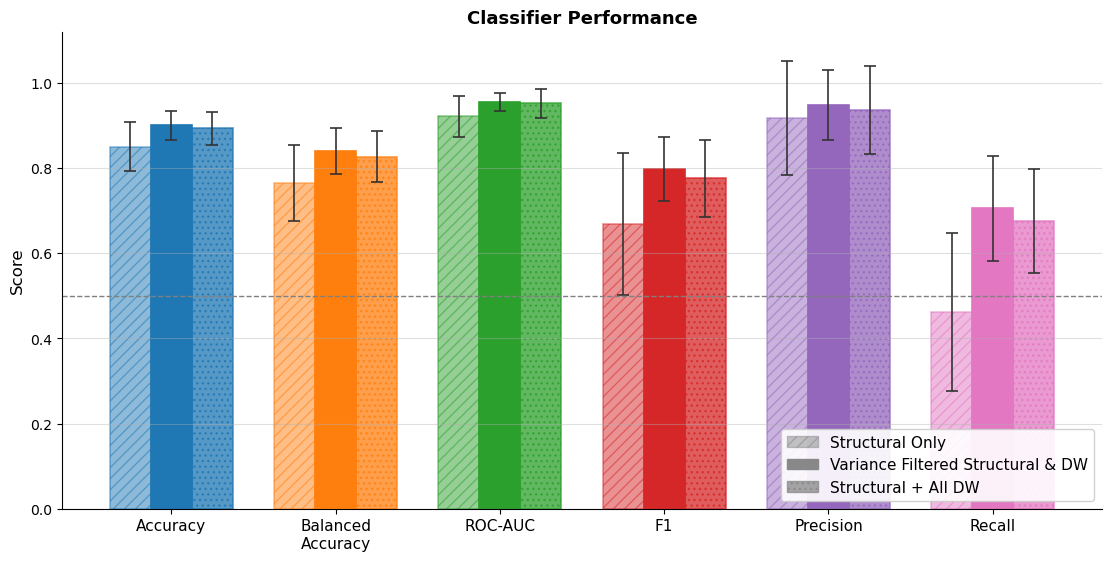

In [16]:
# ── Plot ──────────────────────────────────────────────────────────────────────
colors = ["C0", "C1", "C2", "C3", "C4", "C6"]
x = np.arange(len(metrics))
width = 0.25  # narrower to fit three bars

fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)

offsets = [-width, 0, width]  # left=All, center=Reduced, right=DW

# All Features — hatched bars
for i, (m, s, c) in enumerate(zip(all_mean, all_sd, colors)):
    ax.bar(x[i] + offsets[0], m, width,
           color=c, alpha=0.50,
           hatch='///', edgecolor=c, linewidth=1.2,
           label='All Features' if i == 0 else '_nolegend_',
           yerr=s, capsize=4,
           error_kw=dict(elinewidth=1.2, ecolor='#333333', capthick=1.2))

# All DW Features — dotted bars
for i, (m, s, c) in enumerate(zip(dw_mean, dw_sd, colors)):
    ax.bar(x[i] + offsets[2], m, width,
           color=c, alpha=0.75,
           hatch='...', edgecolor=c, linewidth=1.2,
           label='Avg DW Features' if i == 0 else '_nolegend_',
           yerr=s, capsize=4,
           error_kw=dict(elinewidth=1.2, ecolor='#333333', capthick=1.2))
    
# Variance filtered DW Features — solid bars
for i, (m, s, c) in enumerate(zip(red_mean, red_sd, colors)):
    ax.bar(x[i] + offsets[1], m, width,
           color=c, alpha=1,
           edgecolor=c, linewidth=1.2,
           label='Reduced Features' if i == 0 else '_nolegend_',
           yerr=s, capsize=4,
           error_kw=dict(elinewidth=1.2, ecolor='#333333', capthick=1.2))

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classifier Performance', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.grid(True, alpha=0.4, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="chance")

# Custom legend
legend_elements = [
      Patch(facecolor='#888888', hatch='///', edgecolor='#888888',
          alpha=0.50, label='Structural Only'),
      Patch(facecolor='#888888', edgecolor='#888888',
          alpha=1.0, label='Variance Filtered Structural & DW'),
      Patch(facecolor='#888888', hatch='...', edgecolor='#888888',
          alpha=0.75, label='Structural + All DW'),
]
ax.legend(handles=legend_elements, fontsize=11, framealpha=0.9, loc='lower right')

plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()